# CIFAR-10 Deep Learning Project with Keras

This notebook compares different neural network configurations on the CIFAR-10 dataset. It also performs binary classification for horse detection using frozen and trainable layers, different optimizers, and Monte Carlo Dropout.

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.models import load_model



In [3]:
cifar=keras.datasets.cifar10

In [4]:
(x_train, y_train), (x_test, y_test) = cifar.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [5]:
x_train, x_test = x_train / 255.0, x_test / 255.0


# train model with selu

In [ ]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=x_train[0].shape),
    keras.layers.Dense(512, activation="selu", kernel_initializer=keras.initializers.LecunNormal(seed=None)),
    keras.layers.Dense(256, activation="selu", kernel_initializer=keras.initializers.LecunNormal(seed=None)),
    keras.layers.Dense(128, activation="selu", kernel_initializer=keras.initializers.LecunNormal(seed=None)),
    keras.layers.Dense(10, activation="softmax")
])

In [ ]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

In [ ]:
history = model.fit(x_train, y_train, epochs=50, validation_split=0.2)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - accuracy: 0.2517 - loss: 2.3069 - val_accuracy: 0.3796 - val_loss: 1.7445
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - accuracy: 0.3632 - loss: 1.7690 - val_accuracy: 0.3987 - val_loss: 1.6788
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 27ms/step - accuracy: 0.4058 - loss: 1.6633 - val_accuracy: 0.4144 - val_loss: 1.6263
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.4257 - loss: 1.6065 - val_accuracy: 0.4237 - val_loss: 1.6010
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.4367 - loss: 1.5632 - val_accuracy: 0.4230 - val_loss: 1.5907
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.4537 - loss: 1.5130 - val_accuracy: 0.4579 - val_loss: 1.5626
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.4660 - loss: 1.4812 - val_accuracy: 0.4636 - val_loss: 1.5146
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.4772 -

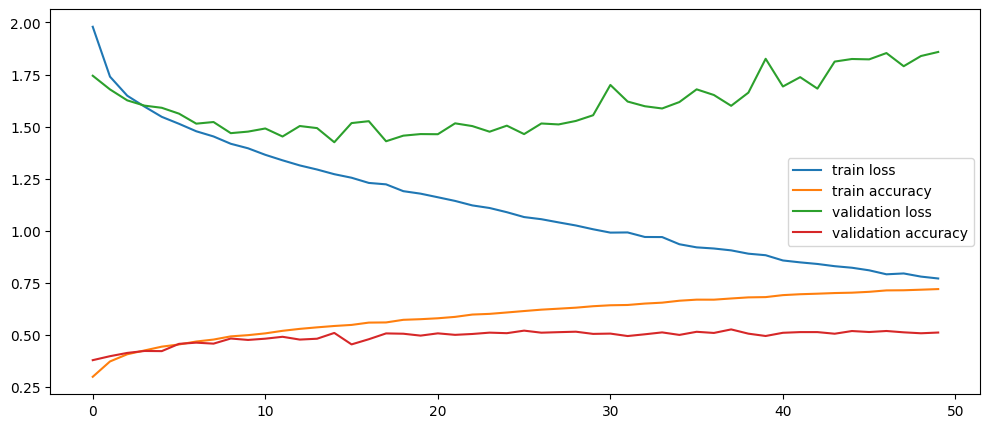

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history.history["loss"], label="train loss")
ax.plot(history.history["accuracy"], label="train accuracy")
ax.plot(history.history["val_loss"], label="validation loss")
ax.plot(history.history["val_accuracy"], label="validation accuracy")
ax.legend()

In [ ]:
np.save('history_selu.npy',history.history)


In [ ]:
np.save('history_selu.npy',history.history)


In [ ]:
his_selu=np.load('my_history.npy',allow_pickle='TRUE').item()


In [ ]:
model.save('model_1_selu.keras')

#Relu with Batch Normalization

In [ ]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=x_train[0].shape),
    keras.layers.Dense(512, activation="relu", kernel_initializer='he_normal'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(256, activation="relu", kernel_initializer='he_normal'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation="relu", kernel_initializer='he_normal'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(10, activation="softmax")
])

In [ ]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

In [ ]:
history_2 = model.fit(x_train, y_train, epochs=50, validation_split=0.2)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.3341 - loss: 1.8900 - val_accuracy: 0.3403 - val_loss: 1.9235
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.4282 - loss: 1.6199 - val_accuracy: 0.3461 - val_loss: 1.8214
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 33ms/step - accuracy: 0.4511 - loss: 1.5303 - val_accuracy: 0.3825 - val_loss: 1.8176
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.4771 - loss: 1.4617 - val_accuracy: 0.4326 - val_loss: 1.6285
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.5012 - loss: 1.3958 - val_accuracy: 0.4152 - val_loss: 1.6607
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.5160 - loss: 1.3622 - val_accuracy: 0.4662 - val_loss: 1.5109
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.5273 - loss: 1.3238 - val_accuracy: 0.4626 - val_loss: 1.5409
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 30ms/step - accuracy: 0.5349 -

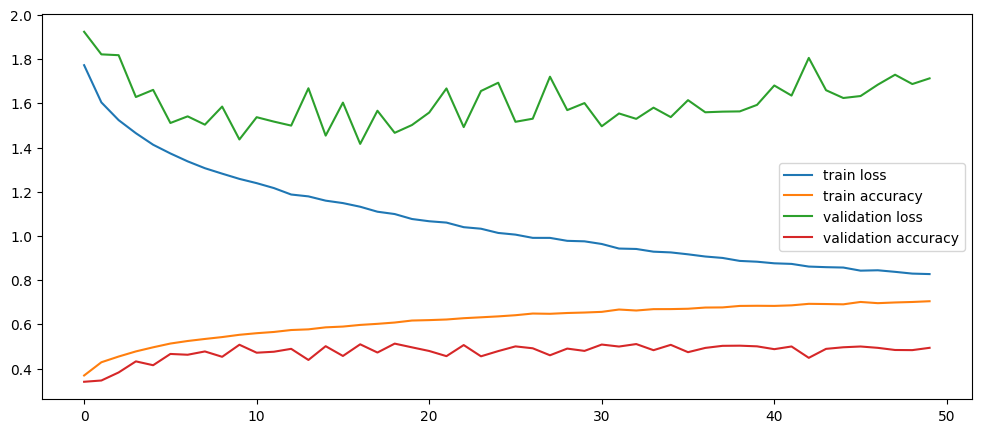

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_2.history["loss"], label="train loss")
ax.plot(history_2.history["accuracy"], label="train accuracy")
ax.plot(history_2.history["val_loss"], label="validation loss")
ax.plot(history_2.history["val_accuracy"], label="validation accuracy")
ax.legend()

In [ ]:
np.save('history_relu.npy',history_2.history)


In [ ]:
model.save('model_2_relu.keras')

##comparing selu and relu with batch normaliztion

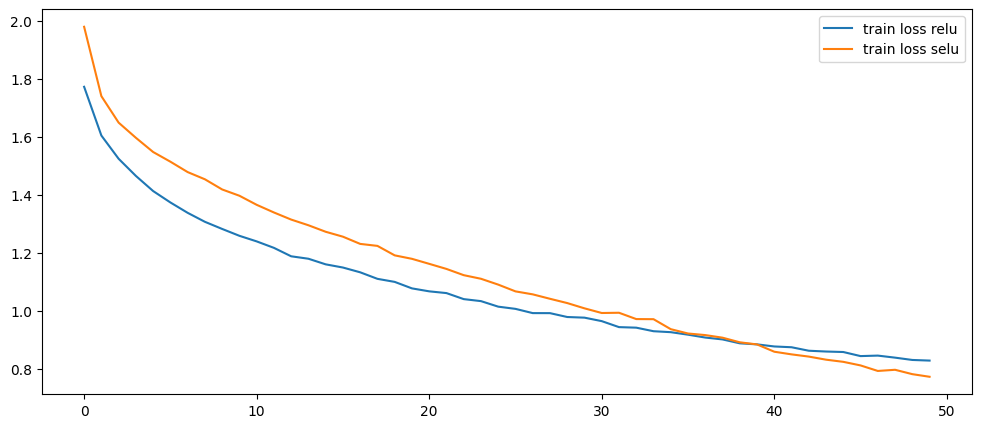

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_2.history["loss"], label="train loss relu")
ax.plot(history.history["loss"], label="train loss selu")
ax.legend()

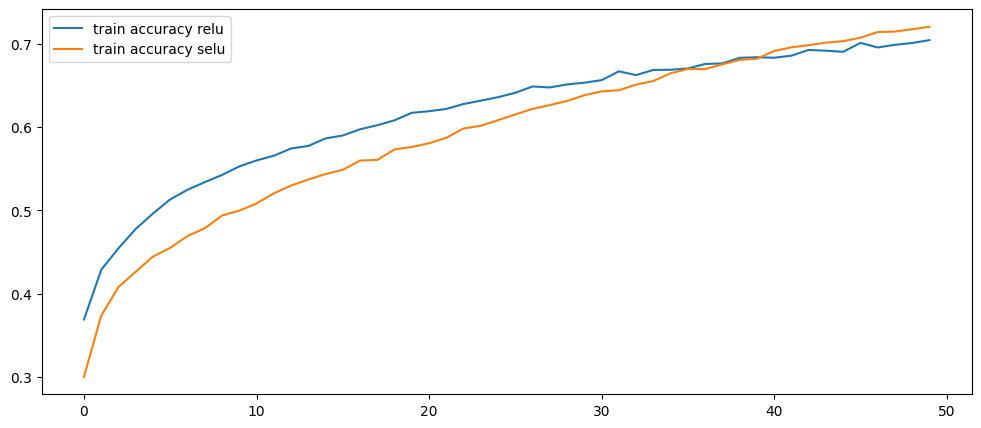

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_2.history["accuracy"], label="train accuracy relu")
ax.plot(history.history["accuracy"], label="train accuracy selu")
ax.legend()

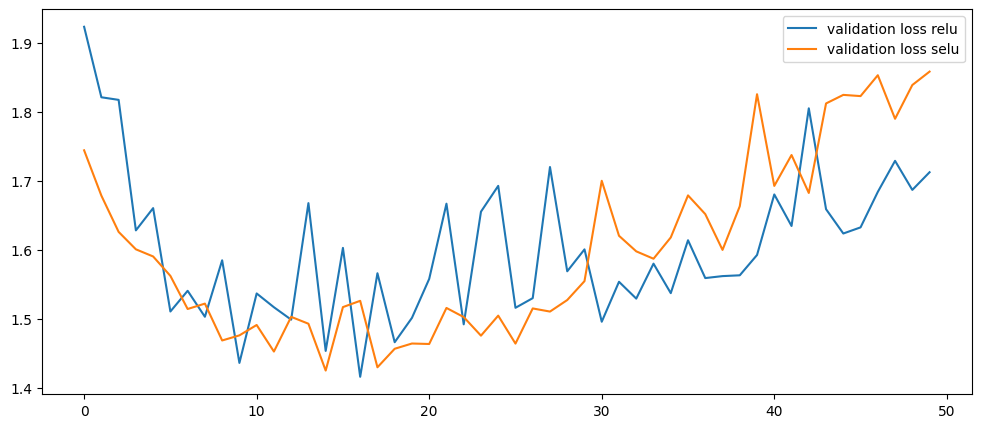

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_2.history["val_loss"], label="validation loss relu")
ax.plot(history.history["val_loss"], label="validation loss selu")
ax.legend()

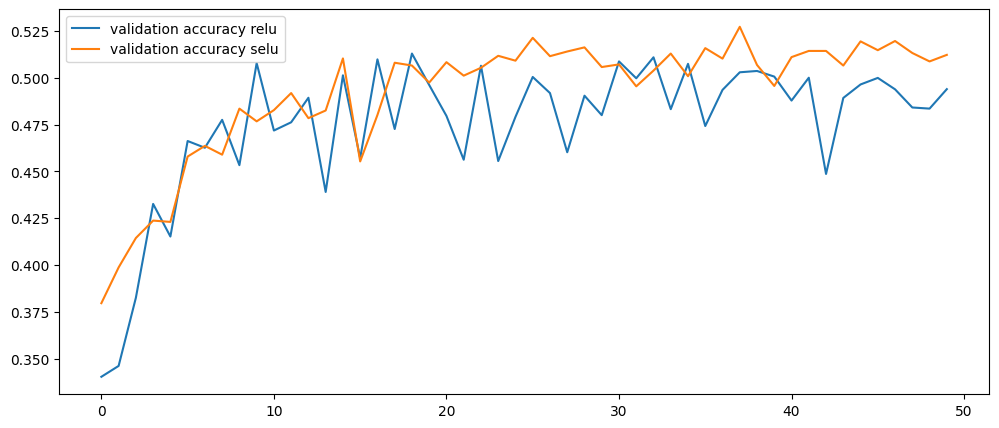

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_2.history["val_accuracy"], label="validation accuracy relu")
ax.plot(history.history["val_accuracy"], label="validation accuracy selu")

ax.legend()

# Binary Classification: Horse vs Non-Horse

## model with untrainable layers

In [6]:
for i in range(0,len(y_train)):
  if y_train[i]==7:
    y_train[i]=1
  else:
    y_train[i]=0

In [7]:
y_train_h=y_train[0:6000]
x_train_h=x_train[0:6000]

In [8]:
y_train_h.sum()

597

In [9]:
np. unique(y_train_h)

array([0, 1], dtype=uint8)

In [15]:
model = load_model('model_2_relu.keras')
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 512)                 │       1,573,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,223,840 (19.93 MB)

 Trainable params: 1,740,682 (6.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

 Optimizer params: 3,481,366 (13.28 MB)

In [16]:
for layer in model.layers[:-1]:
    layer.trainable = False

In [17]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 512)                 │       1,573,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,223,840 (19.93 MB)

 Trainable params: 1,290 (5.04 KB)

 Non-trainable params: 1,741,184 (6.64 MB)

 Optimizer params: 3,481,366 (13.28 MB)

In [18]:
for layer in model.layers:
    print(f"{layer.name}: {layer.trainable}")

flatten_2: False
dense_7: False
batch_normalization: False
dense_8: False
batch_normalization_1: False
dense_9: False
batch_normalization_2: False
dense_10: True


In [22]:
model_new = keras.models.Sequential(model.layers[:-1])
model_new.add(keras.layers.Dense(1, activation="sigmoid"))
model_new.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 512)                 │       1,573,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,741,184 (6.64 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,741,184 (6.64 MB)

In [25]:
model_new.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

In [26]:
start_time = time.time()
history = model_new.fit(x_train_h, y_train_h, epochs=50, validation_split=0.15)
end_time = time.time()
training_time = end_time - start_time
print(f"Training Time for freeze layer: {training_time:.2f} seconds")

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5901 - loss: 0.7260 - val_accuracy: 0.8189 - val_loss: 0.4301
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8466 - loss: 0.3939 - val_accuracy: 0.8678 - val_loss: 0.3394
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8791 - loss: 0.3210 - val_accuracy: 0.8878 - val_loss: 0.2969
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9033 - loss: 0.2650 - val_accuracy: 0.8978 - val_loss: 0.2690
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9109 - loss: 0.2437 - val_accuracy: 0.9100 - val_loss: 0.2505
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9183 - loss: 0.2342 - val_accuracy: 0.9133 - val_loss: 0.2360
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9265 - loss: 0.2196 - val_accuracy: 0.9200 - val_loss: 0.2251
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9300 - loss: 0.2025 - val_accuracy: 0

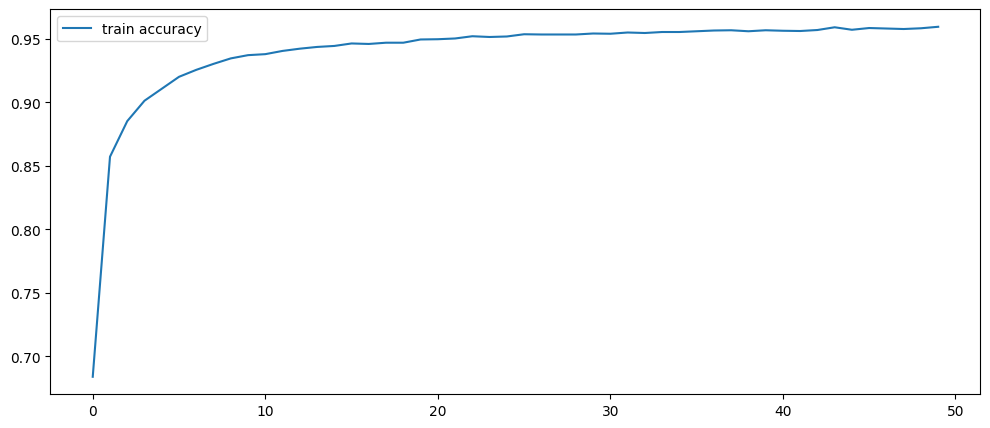

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history.history["accuracy"], label="train accuracy")
ax.legend()

In [28]:
print(f"Training Time for freeze layer: {training_time:.2f} seconds")

Training Time for freeze layer: 72.81 seconds


## model with trainable layers

In [29]:
for layer in model_new.layers[:-1]:
    layer.trainable = True

In [30]:
model_new.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 512)                 │       1,573,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,741,573 (6.64 MB)

 Trainable params: 1,739,521 (6.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

 Optimizer params: 260 (1.02 KB)

In [31]:
model_new.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

In [32]:
start_time = time.time()
history = model_new.fit(x_train_h, y_train_h, epochs=50, validation_split=0.15)
end_time = time.time()
training_time = end_time - start_time
print(f"Training Time for freeze layer: {training_time:.2f} seconds")

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9431 - loss: 0.1464 - val_accuracy: 0.9256 - val_loss: 0.1783
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9570 - loss: 0.1054 - val_accuracy: 0.9356 - val_loss: 0.1728
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9674 - loss: 0.0898 - val_accuracy: 0.9389 - val_loss: 0.1730
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9667 - loss: 0.0834 - val_accuracy: 0.9356 - val_loss: 0.1759
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9777 - loss: 0.0620 - val_accuracy: 0.9256 - val_loss: 0.1871
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9835 - loss: 0.0528 - val_accuracy: 0.9322 - val_loss: 0.2099
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9831 - loss: 0.0523 - val_accuracy: 0.9300 - val_loss: 0.1834
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9892 - loss: 0.0368 - val_accu

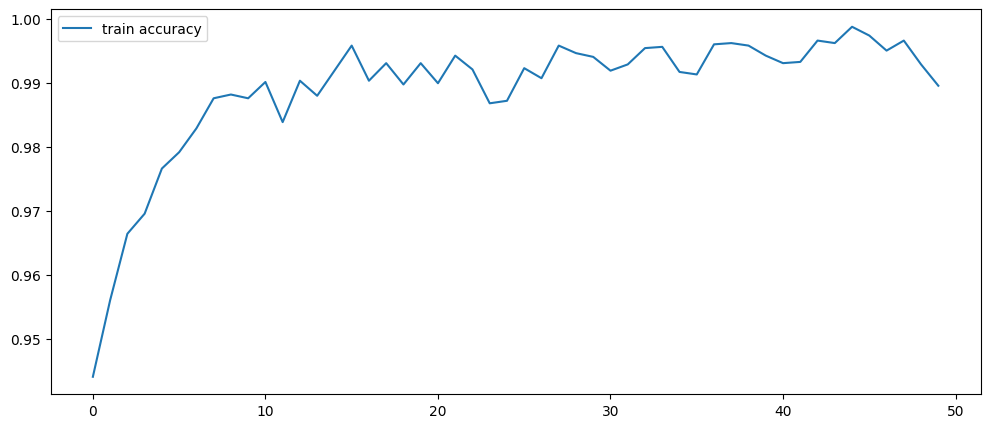

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history.history["accuracy"], label="train accuracy")
ax.legend()

In [33]:
print(f"Training Time for trainable layer: {training_time:.2f} seconds")

Training Time for trainable layer: 236.35 seconds


# training model with different optimizers

In [44]:
model = load_model('model_2_relu.keras')

In [49]:
model_new = keras.models.Sequential(model.layers[:-1])
model_new.add(keras.layers.Dense(1, activation="sigmoid"))

## Adam

In [52]:
model_new.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

In [53]:
history_adam = model_new.fit(x_train_h, y_train_h, epochs=50, validation_split=0.15)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.7387 - loss: 0.5312 - val_accuracy: 0.9144 - val_loss: 0.2468
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9358 - loss: 0.1903 - val_accuracy: 0.9122 - val_loss: 0.2350
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9465 - loss: 0.1463 - val_accuracy: 0.9222 - val_loss: 0.2342
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9602 - loss: 0.1142 - val_accuracy: 0.9289 - val_loss: 0.1852
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9645 - loss: 0.0947 - val_accuracy: 0.9322 - val_loss: 0.1989
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9738 - loss: 0.0801 - val_accuracy: 0.9144 - val_loss: 0.2451
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9701 - loss: 0.0770 - val_accuracy: 0.9322 - val_loss: 0.1892
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9834 - loss: 0.0576 - val_accu

## AdaGrad

In [63]:
model_new2 = keras.models.Sequential(model.layers[:-1])
model_new2.add(keras.layers.Dense(1, activation="sigmoid"))

In [64]:
model_new2.compile(loss="binary_crossentropy",
              optimizer="adagrad",
              metrics=["accuracy"])

In [65]:
history_adagrad = model_new2.fit(x_train_h, y_train_h, epochs=50, validation_split=0.15)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5146 - loss: 0.9369 - val_accuracy: 0.6400 - val_loss: 0.7105
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6850 - loss: 0.6117 - val_accuracy: 0.7056 - val_loss: 0.5870
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7624 - loss: 0.4922 - val_accuracy: 0.7433 - val_loss: 0.5113
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8120 - loss: 0.4119 - val_accuracy: 0.7733 - val_loss: 0.4539
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8509 - loss: 0.3552 - val_accuracy: 0.7978 - val_loss: 0.4186
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8835 - loss: 0.3098 - val_accuracy: 0.8222 - val_loss: 0.3943
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8990 - loss: 0.2796 - val_accuracy: 0.8367 - val_loss: 0.3714
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9108 - loss: 0.2593 - val_accu

## SGD

In [66]:
model_new3 = keras.models.Sequential(model.layers[:-1])
model_new3.add(keras.layers.Dense(1, activation="sigmoid"))

In [67]:
model_new3.compile(loss="binary_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [68]:
history_sgd = model_new3.fit(x_train_h, y_train_h, epochs=50, validation_split=0.15)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8256 - loss: 0.3833 - val_accuracy: 0.9044 - val_loss: 0.2416
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9900 - loss: 0.0660 - val_accuracy: 0.9100 - val_loss: 0.2325
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9941 - loss: 0.0439 - val_accuracy: 0.9111 - val_loss: 0.2350
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9958 - loss: 0.0338 - val_accuracy: 0.9111 - val_loss: 0.2397
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9962 - loss: 0.0275 - val_accuracy: 0.9100 - val_loss: 0.2433
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9965 - loss: 0.0258 - val_accuracy: 0.9111 - val_loss: 0.2466
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9966 - loss: 0.0219 - val_accuracy: 0.9111 - val_loss: 0.2502
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9982 - loss: 0.0189 - val_accu

## Nadam

In [71]:
model_new4 = keras.models.Sequential(model.layers[:-1])
model_new4.add(keras.layers.Dense(1, activation="sigmoid", name="new_dense_layer"))

In [72]:
model_new4.compile(loss="binary_crossentropy",
              optimizer="nadam",
              metrics=["accuracy"])

In [73]:
history_nadam = model_new4.fit(x_train_h, y_train_h, epochs=50, validation_split=0.15)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8725 - loss: 0.3038 - val_accuracy: 0.9200 - val_loss: 0.2432
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9965 - loss: 0.0319 - val_accuracy: 0.9167 - val_loss: 0.2776
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9963 - loss: 0.0193 - val_accuracy: 0.9133 - val_loss: 0.2910
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9983 - loss: 0.0104 - val_accuracy: 0.9178 - val_loss: 0.3025
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9977 - loss: 0.0134 - val_accuracy: 0.9156 - val_loss: 0.3413
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9995 - loss: 0.0071 - val_accuracy: 0.8911 - val_loss: 0.3429
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9983 - loss: 0.0074 - val_accuracy: 0.9000 - val_loss: 0.3727
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9993 - loss: 0.0059 - val_acc

## Nesterov SGD with momentum`

In [76]:
model_new5 = keras.models.Sequential(model.layers[:-1])
model_new5.add(keras.layers.Dense(1, activation="sigmoid", name="new_dense_layer"))

In [77]:
model_new5.compile(loss="binary_crossentropy",
              optimizer=keras.optimizers.SGD( momentum=0.9, nesterov=True),
              metrics=["accuracy"])

In [78]:
history_na_sgd_m = model_new5.fit(x_train_h, y_train_h, epochs=50, validation_split=0.15)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9490 - loss: 0.1147 - val_accuracy: 0.9133 - val_loss: 0.3422
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9994 - loss: 0.0074 - val_accuracy: 0.9133 - val_loss: 0.3674
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9995 - loss: 0.0056 - val_accuracy: 0.9156 - val_loss: 0.3827
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9987 - loss: 0.0042 - val_accuracy: 0.9156 - val_loss: 0.3938
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9995 - loss: 0.0037 - val_accuracy: 0.9156 - val_loss: 0.4000
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9998 - loss: 0.0032 - val_accuracy: 0.9144 - val_loss: 0.4145
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9998 - loss: 0.0028 - val_accuracy: 0.9144 - val_loss: 0.4241
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9996 - loss: 0.0020 - val_accu

## SGD with momentum

In [79]:
model_new6 = keras.models.Sequential(model.layers[:-1])
model_new6.add(keras.layers.Dense(1, activation="sigmoid", name="new_dense_layer"))

In [80]:
model_new6.compile(loss="binary_crossentropy",
              optimizer=keras.optimizers.SGD( momentum=0.9),
              metrics=["accuracy"])

In [81]:
history_sgd_m = model_new6.fit(x_train_h, y_train_h, epochs=50, validation_split=0.15)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9399 - loss: 0.1292 - val_accuracy: 0.9222 - val_loss: 0.3592
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9995 - loss: 0.0041 - val_accuracy: 0.9189 - val_loss: 0.3707
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9995 - loss: 0.0031 - val_accuracy: 0.9156 - val_loss: 0.3864
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9156 - val_loss: 0.4008
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9156 - val_loss: 0.4091
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9995 - loss: 0.0029 - val_accuracy: 0.9156 - val_loss: 0.4165
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9156 - val_loss: 0.4225
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accu

## visualizing metrics

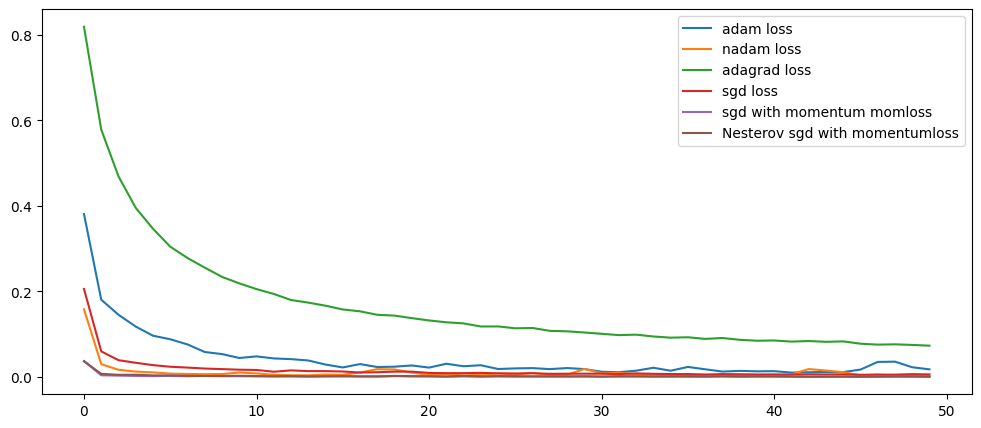

In [82]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_adam.history["loss"], label="adam loss")
ax.plot(history_nadam.history["loss"], label="nadam loss")
ax.plot(history_adagrad.history["loss"], label="adagrad loss")
ax.plot(history_sgd.history["loss"], label="sgd loss")
ax.plot(history_sgd_m.history["loss"], label="sgd with momentum momloss")
ax.plot(history_na_sgd_m.history["loss"], label="Nesterov sgd with momentumloss")
ax.legend()

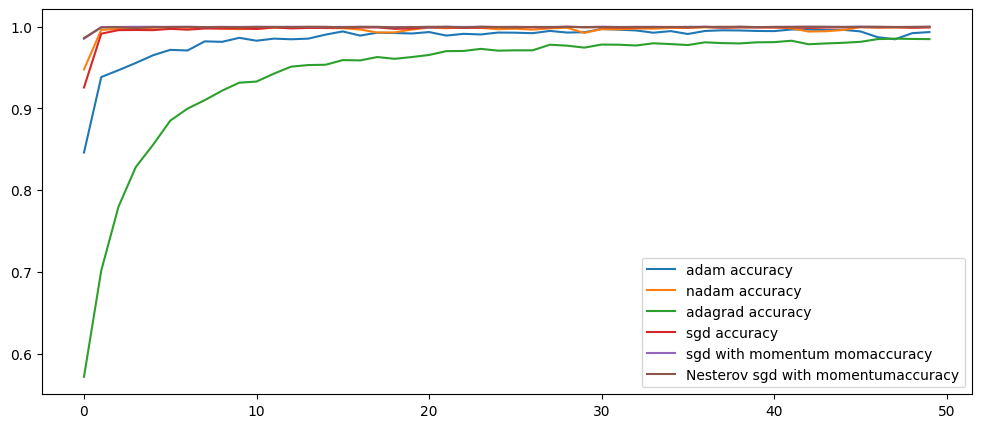

In [83]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_adam.history["accuracy"], label="adam accuracy")
ax.plot(history_nadam.history["accuracy"], label="nadam accuracy")
ax.plot(history_adagrad.history["accuracy"], label="adagrad accuracy")
ax.plot(history_sgd.history["accuracy"], label="sgd accuracy")
ax.plot(history_sgd_m.history["accuracy"], label="sgd with momentum momaccuracy")
ax.plot(history_na_sgd_m.history["accuracy"], label="Nesterov sgd with momentumaccuracy")
ax.legend()

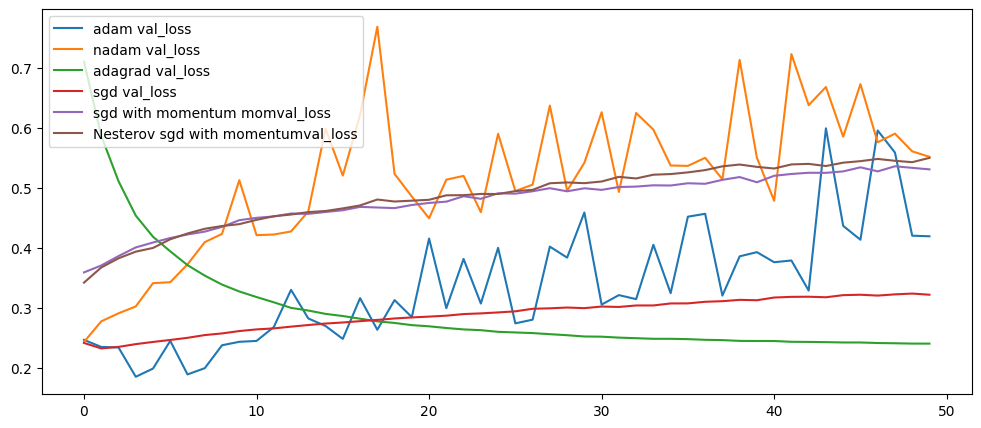

In [84]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_adam.history["val_loss"], label="adam val_loss")
ax.plot(history_nadam.history["val_loss"], label="nadam val_loss")
ax.plot(history_adagrad.history["val_loss"], label="adagrad val_loss")
ax.plot(history_sgd.history["val_loss"], label="sgd val_loss")
ax.plot(history_sgd_m.history["val_loss"], label="sgd with momentum momval_loss")
ax.plot(history_na_sgd_m.history["val_loss"], label="Nesterov sgd with momentumval_loss")
ax.legend()

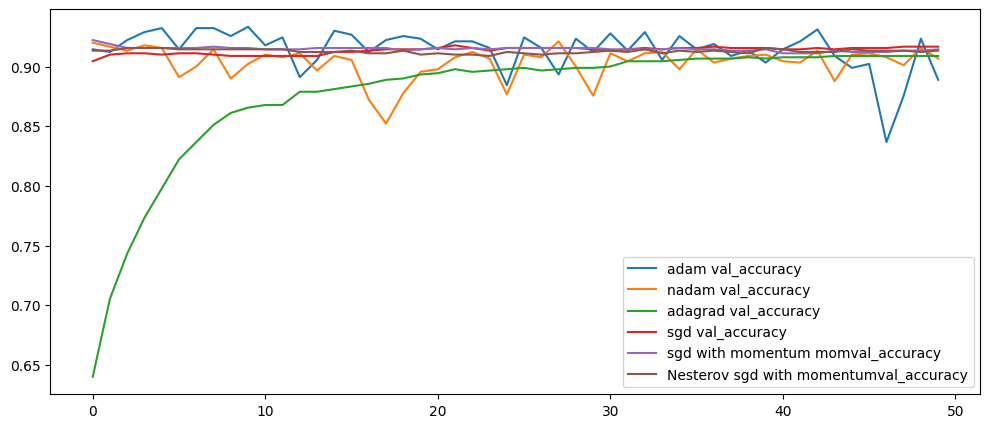

In [85]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_adam.history["val_accuracy"], label="adam val_accuracy")
ax.plot(history_nadam.history["val_accuracy"], label="nadam val_accuracy")
ax.plot(history_adagrad.history["val_accuracy"], label="adagrad val_accuracy")
ax.plot(history_sgd.history["val_accuracy"], label="sgd val_accuracy")
ax.plot(history_sgd_m.history["val_accuracy"], label="sgd with momentum momval_accuracy")
ax.plot(history_na_sgd_m.history["val_accuracy"], label="Nesterov sgd with momentumval_accuracy")
ax.legend()

In [87]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras import regularizers

class MCDropout(Dropout):
    def call(self, inputs):
        return super().call(inputs, training=True)

model_new = keras.models.Sequential(model.layers[:-1])
model_new.add(MCDropout(0.5))
model_new.add(keras.layers.Dense(1, activation="sigmoid",
                                 kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)))

In [88]:
model_new.compile(loss="binary_crossentropy",
                  optimizer="adam",
                  metrics=["accuracy"])

history = model_new.fit(x_train_h, y_train_h,
                        epochs=100,
                        validation_split=0.15)

Epoch 1/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.6241 - loss: 0.9939 - val_accuracy: 0.8700 - val_loss: 0.5198
Epoch 2/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9626 - loss: 0.2403 - val_accuracy: 0.8911 - val_loss: 0.4201
Epoch 3/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9827 - loss: 0.1831 - val_accuracy: 0.9000 - val_loss: 0.4023
Epoch 4/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9865 - loss: 0.1509 - val_accuracy: 0.9067 - val_loss: 0.4070
Epoch 5/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9925 - loss: 0.1260 - val_accuracy: 0.9122 - val_loss: 0.3824
Epoch 6/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9912 - loss: 0.1161 - val_accuracy: 0.9111 - val_loss: 0.3654
Epoch 7/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9953 - loss: 0.1037 - val_accuracy: 0.9144 - val_loss: 0.3563
Epoch 8/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9935 - loss: 0.1040 - 

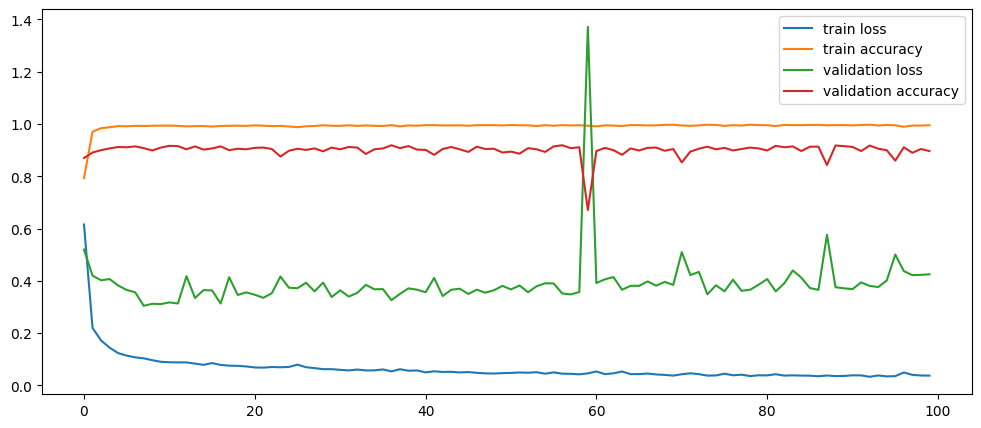

In [89]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history.history["loss"], label="train loss")
ax.plot(history.history["accuracy"], label="train accuracy")
ax.plot(history.history["val_loss"], label="validation loss")
ax.plot(history.history["val_accuracy"], label="validation accuracy")
ax.legend()